In [1]:
# Cell 1 — Imports and project setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from pathlib import Path
from scipy import signal
from scipy.signal import butter, sosfiltfilt, find_peaks

print("=" * 70)
print("NOTEBOOK 04 — PRECURSOR RISK LABELING")
print("=" * 70)

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("WFDB version:", wfdb.__version__)

# Project paths
PROJECT_ROOT = Path("..")
REPORTS_DIR = PROJECT_ROOT / "reports"
DATA_DIR = PROJECT_ROOT / "data"

# PICS database
PICS_PATH = "picsdb/1.0.0"

# Sampling frequencies for PICS Infant 1
ECG_FS = 250
RESP_FS = 500

print("\nProject setup:")
print("Reports directory:", REPORTS_DIR)
print("Data directory:", DATA_DIR)
print("PICS database:", PICS_PATH)
print("ECG sampling rate:", ECG_FS, "Hz")
print("Respiration sampling rate:", RESP_FS, "Hz")

NOTEBOOK 04 — PRECURSOR RISK LABELING
NumPy version: 2.5.2
Pandas version: 3.0.5
WFDB version: 4.3.1

Project setup:
Reports directory: ..\reports
Data directory: ..\data
PICS database: picsdb/1.0.0
ECG sampling rate: 250 Hz
Respiration sampling rate: 500 Hz


In [2]:
# Cell 2 — Load Notebook 03 event-detection checkpoint

event_summary_path = REPORTS_DIR / "pics_event_detection_summary.csv"

event_summary = pd.read_csv(event_summary_path)

print("=" * 70)
print("LOADED EVENT DETECTION CHECKPOINT")
print("=" * 70)

print("File:", event_summary_path)
print("Rows:", len(event_summary))
print("Columns:", len(event_summary.columns))

display(event_summary)

LOADED EVENT DETECTION CHECKPOINT
File: ..\reports\pics_event_detection_summary.csv
Rows: 10
Columns: 6


,event_number,bradycardia_onset_s,short_resp_with_brady_count,bradycardia_only_count,qualifying_resp_suppression_count,total_classified_periods
0,1,1971.372,0,0,0,0
1,2,3456.512,1,1,1,2
2,3,3937.996,0,2,0,2
3,4,4834.748,0,1,0,1
4,5,7696.272,0,1,0,1
5,6,8246.660,0,2,0,2
6,7,13109.660,2,0,2,2
7,8,14684.788,0,1,0,1
8,9,16371.744,0,1,0,1
9,10,17118.100,0,0,0,0


In [3]:
# Cell 3 — Precursor / risk-labeling configuration

# -------------------------------------------------
# Precursor window
# -------------------------------------------------

PRECURSOR_WINDOW = 15.0       # seconds before event onset
EVENT_EXCLUSION = 0.0         # event onset is the boundary; no post-onset data

# -------------------------------------------------
# Analysis window for physiological features
# -------------------------------------------------

FEATURE_WINDOW = 5.0          # seconds per feature window
FEATURE_STEP = 1.0            # seconds between consecutive windows

# -------------------------------------------------
# Risk labels
# -------------------------------------------------

RISK_NORMAL = 0
RISK_PRECURSOR = 1

# Events classified as short respiratory suppression
# associated with bradycardia are the current positive
# PICS-derived precursor targets.
positive_events = event_summary[
    event_summary["short_resp_with_brady_count"] > 0
].copy()

print("=" * 70)
print("PRECURSOR RISK-LABELING CONFIGURATION")
print("=" * 70)

print("Precursor window:", PRECURSOR_WINDOW, "seconds")
print("Feature window:", FEATURE_WINDOW, "seconds")
print("Feature step:", FEATURE_STEP, "seconds")
print("Normal label:", RISK_NORMAL)
print("Precursor label:", RISK_PRECURSOR)

print("\nPICS-derived positive target events:")
display(
    positive_events[
        ["event_number", "bradycardia_onset_s",
         "short_resp_with_brady_count"]
    ]
)

PRECURSOR RISK-LABELING CONFIGURATION
Precursor window: 15.0 seconds
Feature window: 5.0 seconds
Feature step: 1.0 seconds
Normal label: 0
Precursor label: 1

PICS-derived positive target events:


,event_number,bradycardia_onset_s,short_resp_with_brady_count
1,2,3456.512,1
6,7,13109.660,2


In [5]:
# Cell 4 — Efficient event-centered signal loading

# -------------------------------------------------
# We only need signal around the positive target
# events at this stage.
# -------------------------------------------------

TARGET_EVENTS = positive_events["bradycardia_onset_s"].to_numpy()

# Include the 15-second precursor window plus a small
# margin before it for filtering edge effects.
FILTER_MARGIN = 5.0

print("=" * 70)
print("EVENT-CENTERED SIGNAL LOADING")
print("=" * 70)

event_windows = {}

for event_number, event_time in zip(
    positive_events["event_number"],
    TARGET_EVENTS
):

    load_start = event_time - PRECURSOR_WINDOW - FILTER_MARGIN
    load_end = event_time + FILTER_MARGIN

    print(
        f"\nEvent {int(event_number)}:"
        f" {event_time:.3f} s"
    )
    print(
        f"Loading: {load_start:.3f} to {load_end:.3f} s"
    )

    # ECG
    ecg_record_event = wfdb.rdrecord(
        "infant1_ecg",
        pn_dir=PICS_PATH,
        sampfrom=int(load_start * ECG_FS),
        sampto=int(load_end * ECG_FS)
    )

    # Respiration
    resp_record_event = wfdb.rdrecord(
        "infant1_resp",
        pn_dir=PICS_PATH,
        sampfrom=int(load_start * RESP_FS),
        sampto=int(load_end * RESP_FS)
    )

    event_windows[int(event_number)] = {
        "event_time": event_time,
        "load_start": load_start,
        "load_end": load_end,
        "ecg": ecg_record_event.p_signal[:, 0],
        "respiration": resp_record_event.p_signal[:, 0]
    }

    print(
        "ECG samples:",
        len(event_windows[int(event_number)]["ecg"])
    )
    print(
        "Respiration samples:",
        len(event_windows[int(event_number)]["respiration"])
    )

print("\nEvent-centered loading complete.")
print("Events loaded:", list(event_windows.keys()))

EVENT-CENTERED SIGNAL LOADING

Event 2: 3456.512 s
Loading: 3436.512 to 3461.512 s
ECG samples: 6250
Respiration samples: 12500

Event 7: 13109.660 s
Loading: 13089.660 to 13114.660 s
ECG samples: 6250
Respiration samples: 12500

Event-centered loading complete.
Events loaded: [2, 7]


In [6]:
# Cell 5 — Preprocessing filters for precursor analysis

print("=" * 70)
print("PRECURSOR ANALYSIS FILTERS")
print("=" * 70)

# -------------------------------------------------
# ECG filter
# Bandpass: 0.5–40 Hz
# Butterworth order: 4
# -------------------------------------------------

ECG_LOW = 0.5
ECG_HIGH = 40.0
ECG_FILTER_ORDER = 4

sos_ecg_precursor = butter(
    ECG_FILTER_ORDER,
    [ECG_LOW, ECG_HIGH],
    btype="bandpass",
    fs=ECG_FS,
    output="sos"
)

# -------------------------------------------------
# Respiration filter
# Apnea-oriented: 0.03–2.0 Hz
# Butterworth order: 4
# -------------------------------------------------

RESP_LOW_APNEA = 0.03
RESP_HIGH_APNEA = 2.0
RESP_FILTER_ORDER = 4

sos_resp_precursor = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW_APNEA, RESP_HIGH_APNEA],
    btype="bandpass",
    fs=RESP_FS,
    output="sos"
)

print("ECG bandpass:", ECG_LOW, "–", ECG_HIGH, "Hz")
print("ECG filter order:", ECG_FILTER_ORDER)

print("\nRespiration bandpass:", RESP_LOW_APNEA, "–", RESP_HIGH_APNEA, "Hz")
print("Respiration filter order:", RESP_FILTER_ORDER)

print("\nFilter design complete.")

PRECURSOR ANALYSIS FILTERS
ECG bandpass: 0.5 – 40.0 Hz
ECG filter order: 4

Respiration bandpass: 0.03 – 2.0 Hz
Respiration filter order: 4

Filter design complete.


In [7]:
# Cell 6 — Preprocess event-centered signals

print("=" * 70)
print("PREPROCESSING EVENT-CENTERED SIGNALS")
print("=" * 70)

for event_number, data in event_windows.items():

    # -------------------------------------------------
    # ECG preprocessing
    # -------------------------------------------------

    data["ecg_filtered"] = sosfiltfilt(
        sos_ecg_precursor,
        data["ecg"]
    )

    # -------------------------------------------------
    # Respiration preprocessing
    # -------------------------------------------------

    data["respiration_filtered"] = sosfiltfilt(
        sos_resp_precursor,
        data["respiration"]
    )

    print(f"\nEvent {event_number}:")
    print(
        "  ECG raw samples:",
        len(data["ecg"])
    )
    print(
        "  ECG filtered samples:",
        len(data["ecg_filtered"])
    )
    print(
        "  Respiration raw samples:",
        len(data["respiration"])
    )
    print(
        "  Respiration filtered samples:",
        len(data["respiration_filtered"])
    )

print("\nPreprocessing complete.")

PREPROCESSING EVENT-CENTERED SIGNALS

Event 2:
  ECG raw samples: 6250
  ECG filtered samples: 6250
  Respiration raw samples: 12500
  Respiration filtered samples: 12500

Event 7:
  ECG raw samples: 6250
  ECG filtered samples: 6250
  Respiration raw samples: 12500
  Respiration filtered samples: 12500

Preprocessing complete.


In [8]:
# Cell 7 — Extract 15-second precursor windows

print("=" * 70)
print("EXTRACTING PRECURSOR WINDOWS")
print("=" * 70)

for event_number, data in event_windows.items():

    event_time = data["event_time"]
    load_start = data["load_start"]

    # Precursor window in absolute time
    precursor_start = event_time - PRECURSOR_WINDOW
    precursor_end = event_time

    # Convert absolute time to indices relative to loaded signal
    ecg_start = int(
        (precursor_start - load_start) * ECG_FS
    )
    ecg_end = int(
        (precursor_end - load_start) * ECG_FS
    )

    resp_start = int(
        (precursor_start - load_start) * RESP_FS
    )
    resp_end = int(
        (precursor_end - load_start) * RESP_FS
    )

    # Extract only the precursor region
    data["ecg_precursor"] = data["ecg_filtered"][ecg_start:ecg_end]
    data["respiration_precursor"] = (
        data["respiration_filtered"][resp_start:resp_end]
    )

    data["precursor_start"] = precursor_start
    data["precursor_end"] = precursor_end

    print(f"\nEvent {event_number}:")
    print(
        f"  Precursor: "
        f"{precursor_start:.3f} → {precursor_end:.3f} s"
    )
    print(
        "  ECG samples:",
        len(data["ecg_precursor"]),
        "(expected:", int(PRECURSOR_WINDOW * ECG_FS), ")"
    )
    print(
        "  Respiration samples:",
        len(data["respiration_precursor"]),
        "(expected:", int(PRECURSOR_WINDOW * RESP_FS), ")"
    )

print("\nPrecursor extraction complete.")

EXTRACTING PRECURSOR WINDOWS

Event 2:
  Precursor: 3441.512 → 3456.512 s
  ECG samples: 3750 (expected: 3750 )
  Respiration samples: 7500 (expected: 7500 )

Event 7:
  Precursor: 13094.660 → 13109.660 s
  ECG samples: 3750 (expected: 3750 )
  Respiration samples: 7500 (expected: 7500 )

Precursor extraction complete.


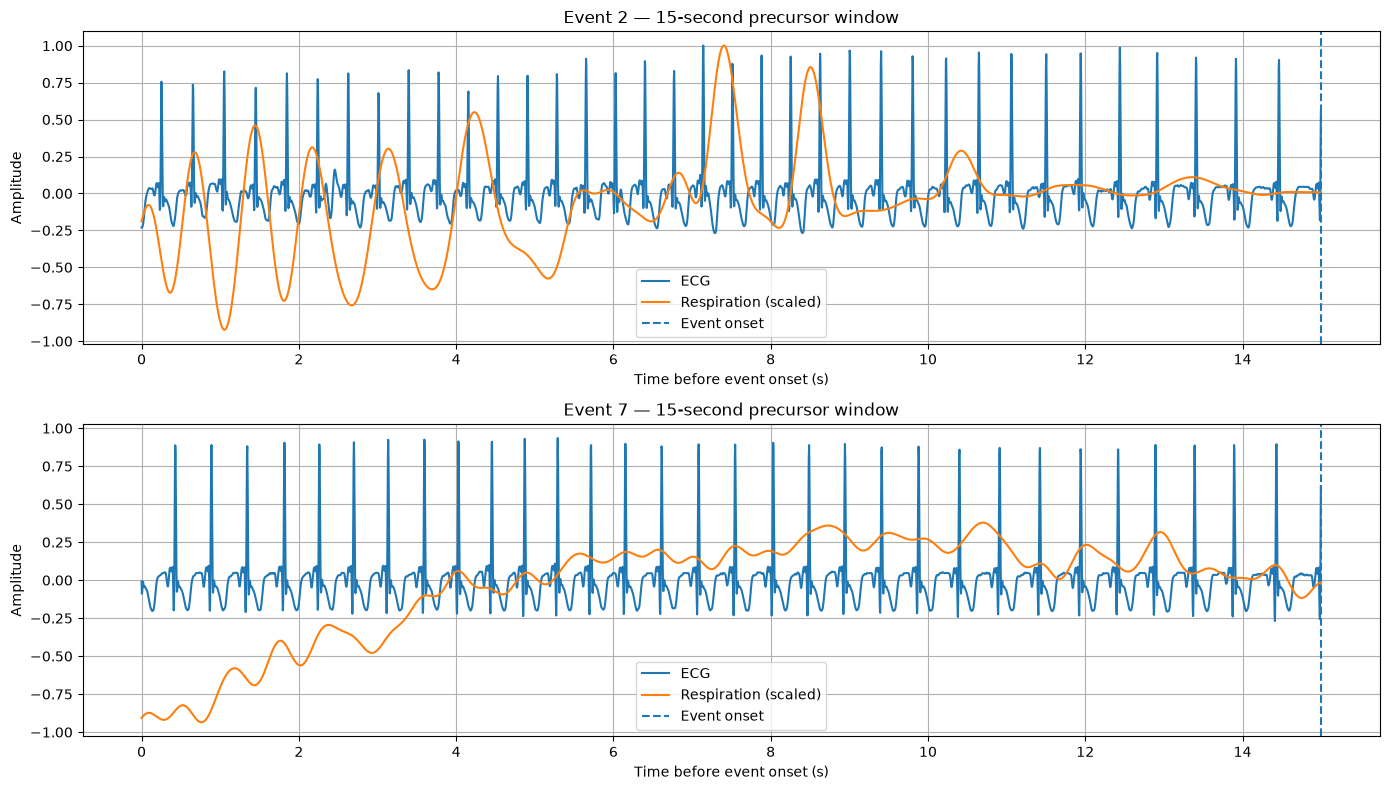

In [9]:
# Cell 8 — Visual verification of precursor windows

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=False
)

for ax, (event_number, data) in zip(axes, event_windows.items()):

    ecg_time = np.arange(
        len(data["ecg_precursor"])
    ) / ECG_FS

    resp_time = np.arange(
        len(data["respiration_precursor"])
    ) / RESP_FS

    ax.plot(
        ecg_time,
        data["ecg_precursor"],
        label="ECG"
    )

    # Scale respiration for visual overlay
    respiration_scaled = (
        data["respiration_precursor"]
        / np.max(np.abs(data["respiration_precursor"]))
        * np.max(np.abs(data["ecg_precursor"]))
    )

    ax.plot(
        resp_time,
        respiration_scaled,
        label="Respiration (scaled)"
    )

    ax.axvline(
        PRECURSOR_WINDOW,
        linestyle="--",
        label="Event onset"
    )

    ax.set_title(
        f"Event {event_number} — 15-second precursor window"
    )

    ax.set_xlabel("Time before event onset (s)")
    ax.set_ylabel("Amplitude")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Cell 9 — Calculate basic precursor physiological features

def calculate_precursor_features(ecg_signal, respiration_signal, ecg_fs, resp_fs):
    features = {}

    # --------------------------------------------------
    # ECG features
    # --------------------------------------------------
    ecg_mean = np.mean(ecg_signal)
    ecg_std = np.std(ecg_signal)
    ecg_rms = np.sqrt(np.mean(ecg_signal ** 2))

    # Detect R-peaks
    ecg_distance = int(0.25 * ecg_fs)

    r_peaks, _ = find_peaks(
        ecg_signal,
        distance=ecg_distance,
        prominence=0.3 * np.std(ecg_signal)
    )

    features["ecg_mean"] = ecg_mean
    features["ecg_std"] = ecg_std
    features["ecg_rms"] = ecg_rms
    features["r_peak_count"] = len(r_peaks)

    # RR intervals
    if len(r_peaks) >= 2:
        rr_intervals = np.diff(r_peaks) / ecg_fs

        features["mean_rr"] = np.mean(rr_intervals)
        features["std_rr"] = np.std(rr_intervals)

        # Heart rate
        hr = 60.0 / rr_intervals

        # Remove physiologically extreme detector artifacts
        hr_valid = hr[(hr >= 30) & (hr <= 220)]

        if len(hr_valid) > 0:
            features["mean_hr"] = np.mean(hr_valid)
            features["min_hr"] = np.min(hr_valid)
            features["max_hr"] = np.max(hr_valid)
            features["std_hr"] = np.std(hr_valid)
        else:
            features["mean_hr"] = np.nan
            features["min_hr"] = np.nan
            features["max_hr"] = np.nan
            features["std_hr"] = np.nan

        # HRV
        if len(rr_intervals) >= 2:
            features["sdnn"] = np.std(rr_intervals, ddof=1)
            features["rmssd"] = np.sqrt(
                np.mean(np.diff(rr_intervals) ** 2)
            )
        else:
            features["sdnn"] = np.nan
            features["rmssd"] = np.nan

    else:
        features["mean_rr"] = np.nan
        features["std_rr"] = np.nan
        features["mean_hr"] = np.nan
        features["min_hr"] = np.nan
        features["max_hr"] = np.nan
        features["std_hr"] = np.nan
        features["sdnn"] = np.nan
        features["rmssd"] = np.nan

    # --------------------------------------------------
    # Respiration features
    # --------------------------------------------------
    respiration_mean = np.mean(respiration_signal)
    respiration_std = np.std(respiration_signal)
    respiration_rms = np.sqrt(
        np.mean(respiration_signal ** 2)
    )

    features["resp_mean"] = respiration_mean
    features["resp_std"] = respiration_std
    features["resp_rms"] = respiration_rms

    # Respiration peak detection
    resp_distance = int(0.8 * resp_fs)

    resp_peaks, _ = find_peaks(
        respiration_signal,
        distance=resp_distance,
        prominence=0.1 * np.std(respiration_signal)
    )

    features["resp_peak_count"] = len(resp_peaks)

    if len(resp_peaks) >= 2:
        resp_intervals = np.diff(resp_peaks) / resp_fs

        features["mean_resp_interval"] = np.mean(resp_intervals)
        features["std_resp_interval"] = np.std(resp_intervals)

        # Respiratory rate in breaths/min
        resp_rate = 60.0 / resp_intervals

        resp_rate_valid = resp_rate[
            (resp_rate >= 3) & (resp_rate <= 100)
        ]

        if len(resp_rate_valid) > 0:
            features["mean_resp_rate"] = np.mean(resp_rate_valid)
            features["std_resp_rate"] = np.std(resp_rate_valid)
        else:
            features["mean_resp_rate"] = np.nan
            features["std_resp_rate"] = np.nan

    else:
        features["mean_resp_interval"] = np.nan
        features["std_resp_interval"] = np.nan
        features["mean_resp_rate"] = np.nan
        features["std_resp_rate"] = np.nan

    return features


# Calculate features for every positive event
precursor_features = []

for event_number, data in event_windows.items():

    features = calculate_precursor_features(
        data["ecg_precursor"],
        data["respiration_precursor"],
        ECG_FS,
        RESP_FS
    )

    features["event_number"] = event_number
    features["event_time"] = data["event_time"]
    features["risk_label"] = RISK_PRECURSOR

    precursor_features.append(features)


precursor_features_df = pd.DataFrame(precursor_features)

# Put identifying columns first
column_order = [
    "event_number",
    "event_time",
    "risk_label"
] + [
    col for col in precursor_features_df.columns
    if col not in ["event_number", "event_time", "risk_label"]
]

precursor_features_df = precursor_features_df[column_order]

print("=" * 70)
print("PRECURSOR FEATURE EXTRACTION")
print("=" * 70)

display(precursor_features_df.round(4))

print("\nFeature extraction complete.")

PRECURSOR FEATURE EXTRACTION


,event_number,event_time,risk_label,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,std_rr,mean_hr,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,2,3456.512,1,-0.0001,0.1821,0.1821,38,0.3977,0.0507,151.0313,...,0.0514,0.0576,-0.1084,0.7339,0.7418,10,1.4747,0.2561,41.9997,7.6819
1,7,13109.660,1,-0.0007,0.1707,0.1707,33,0.4672,0.0345,129.0997,...,0.0351,0.0211,-0.0048,0.0523,0.0525,12,1.3018,0.3086,48.5205,10.4927



Feature extraction complete.


In [12]:
# Cell 10 — Create sliding 5-second windows inside each precursor

WINDOW_SECONDS = FEATURE_WINDOW
STEP_SECONDS = FEATURE_STEP

sliding_windows = []

for event_number, data in event_windows.items():

    event_time = data["event_time"]
    precursor_start = data["precursor_start"]
    precursor_end = data["precursor_end"]

    window_start = precursor_start

    while window_start + WINDOW_SECONDS <= precursor_end:

        window_end = window_start + WINDOW_SECONDS

        ecg_start = int(
            (window_start - precursor_start) * ECG_FS
        )
        ecg_end = int(
            (window_end - precursor_start) * ECG_FS
        )

        resp_start = int(
            (window_start - precursor_start) * RESP_FS
        )
        resp_end = int(
            (window_end - precursor_start) * RESP_FS
        )

        sliding_windows.append({
            "event_number": event_number,
            "event_time": event_time,
            "window_start": window_start,
            "window_end": window_end,
            "time_to_event": event_time - window_end,
            "ecg": data["ecg_precursor"][ecg_start:ecg_end],
            "respiration": data["respiration_precursor"][resp_start:resp_end],
            "risk_label": RISK_PRECURSOR
        })

        window_start += STEP_SECONDS


sliding_windows_df = pd.DataFrame([
    {
        "event_number": w["event_number"],
        "window_start": w["window_start"],
        "window_end": w["window_end"],
        "time_to_event": w["time_to_event"],
        "risk_label": w["risk_label"],
        "ecg_samples": len(w["ecg"]),
        "resp_samples": len(w["respiration"])
    }
    for w in sliding_windows
])

print("=" * 70)
print("SLIDING PRECURSOR WINDOWS")
print("=" * 70)

print(f"Total windows: {len(sliding_windows)}")
print(f"Expected windows: {len(event_windows) * 11}")

print("\nWindows per event:")
print(
    sliding_windows_df
    .groupby("event_number")
    .size()
)

print("\nWindow summary:")
display(sliding_windows_df.round(3))

SLIDING PRECURSOR WINDOWS
Total windows: 22
Expected windows: 22

Windows per event:
event_number
2    11
7    11
dtype: int64

Window summary:


,event_number,window_start,window_end,time_to_event,risk_label,ecg_samples,resp_samples
0,2,3441.512,3446.512,10.0,1,1250,2500
1,2,3442.512,3447.512,9.0,1,1250,2500
2,2,3443.512,3448.512,8.0,1,1250,2500
3,2,3444.512,3449.512,7.0,1,1250,2500
4,2,3445.512,3450.512,6.0,1,1250,2500
5,2,3446.512,3451.512,5.0,1,1250,2500
6,2,3447.512,3452.512,4.0,1,1250,2500
7,2,3448.512,3453.512,3.0,1,1250,2500
8,2,3449.512,3454.512,2.0,1,1250,2500
9,2,3450.512,3455.512,1.0,1,1250,2500


In [13]:
# Cell 11 — Extract features from every 5-second precursor window

window_feature_rows = []

for window in sliding_windows:

    features = calculate_precursor_features(
        window["ecg"],
        window["respiration"],
        ECG_FS,
        RESP_FS
    )

    features["event_number"] = window["event_number"]
    features["event_time"] = window["event_time"]
    features["window_start"] = window["window_start"]
    features["window_end"] = window["window_end"]
    features["time_to_event"] = window["time_to_event"]
    features["risk_label"] = window["risk_label"]

    window_feature_rows.append(features)


precursor_feature_dataset = pd.DataFrame(window_feature_rows)

# Put identification / timing columns first
metadata_columns = [
    "event_number",
    "event_time",
    "window_start",
    "window_end",
    "time_to_event",
    "risk_label"
]

feature_columns = [
    col for col in precursor_feature_dataset.columns
    if col not in metadata_columns
]

precursor_feature_dataset = precursor_feature_dataset[
    metadata_columns + feature_columns
]

print("=" * 70)
print("5-SECOND PRECURSOR FEATURE DATASET")
print("=" * 70)

print(f"Total rows: {len(precursor_feature_dataset)}")
print(f"Total columns: {len(precursor_feature_dataset.columns)}")

print("\nRows per event:")
print(
    precursor_feature_dataset
    .groupby("event_number")
    .size()
)

print("\nDataset:")
display(precursor_feature_dataset.round(4))

5-SECOND PRECURSOR FEATURE DATASET
Total rows: 22
Total columns: 26

Rows per event:
event_number
2    11
7    11
dtype: int64

Dataset:


,event_number,event_time,window_start,window_end,time_to_event,risk_label,ecg_mean,ecg_std,ecg_rms,r_peak_count,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,2,3456.512,3441.512,3446.512,10.0,1,0.0010,0.1677,0.1677,13,...,0.0093,0.0030,-0.4830,0.8881,1.0109,4,1.3813,0.2456,44.8372,7.9414
1,2,3456.512,3442.512,3447.512,9.0,1,-0.0003,0.1715,0.1715,13,...,0.0092,0.0032,-0.4637,0.8621,0.9789,3,1.3940,0.3000,45.1319,9.7127
2,2,3456.512,3443.512,3448.512,8.0,1,-0.0016,0.1754,0.1754,13,...,0.0055,0.0030,-0.3519,0.7365,0.8163,5,1.1650,0.3142,54.6811,11.8966
3,2,3456.512,3444.512,3449.512,7.0,1,0.0020,0.1880,0.1880,14,...,0.0044,0.0031,-0.0932,0.8409,0.8461,4,1.4220,0.2487,43.6241,8.2209
4,2,3456.512,3445.512,3450.512,6.0,1,0.0006,0.1897,0.1897,14,...,0.0170,0.0175,0.1055,0.8455,0.8521,4,1.4247,0.2452,43.4914,8.0399
5,2,3456.512,3446.512,3451.512,5.0,1,-0.0032,0.1990,0.1990,13,...,0.0109,0.0077,0.0646,0.7701,0.7728,3,1.2890,0.1870,47.5484,6.8980
6,2,3456.512,3447.512,3452.512,4.0,1,-0.0002,0.2003,0.2003,13,...,0.0205,0.0119,0.2052,0.6843,0.7144,3,1.5090,0.4070,42.8809,11.5656
7,2,3456.512,3448.512,3453.512,3.0,1,0.0051,0.2026,0.2026,13,...,0.0276,0.0155,0.2379,0.6643,0.7056,3,1.5090,0.4070,42.8809,11.5656
8,2,3456.512,3449.512,3454.512,2.0,1,0.0004,0.1959,0.1959,12,...,0.0393,0.0270,0.1069,0.4665,0.4786,3,1.6850,0.2310,36.2904,4.9751
9,2,3456.512,3450.512,3455.512,1.0,1,0.0026,0.1925,0.1925,12,...,0.0406,0.0269,0.0510,0.1967,0.2032,3,1.4690,0.0150,40.8484,0.4171


In [14]:
# Cell 12 — Select negative/control windows away from annotated bradycardia

CONTROL_COUNT = len(sliding_windows)
CONTROL_EXCLUSION = 60.0
CONTROL_WINDOW = FEATURE_WINDOW

# Load official PICS bradycardia annotation times
brady_annotation = wfdb.rdann(
    "infant1_ecg",
    "atr",
    pn_dir=PICS_PATH
)

brady_times_all = brady_annotation.sample / ECG_FS

print("=" * 70)
print("CONTROL WINDOW SELECTION")
print("=" * 70)

print(f"Total bradycardia annotations: {len(brady_times_all)}")

# Candidate 5-second windows across the record
# Start well after the beginning and leave enough room at the end.
record_duration = 41052191 / ECG_FS

candidate_starts = np.arange(
    60.0,
    record_duration - CONTROL_WINDOW - 60.0,
    CONTROL_WINDOW
)

control_windows = []

for start_time in candidate_starts:

    end_time = start_time + CONTROL_WINDOW

    # Do not use a control window if it is close to any
    # annotated bradycardia onset.
    distance_to_brady = np.min(
        np.abs(brady_times_all - start_time)
    )

    distance_to_brady_end = np.min(
        np.abs(brady_times_all - end_time)
    )

    if (
        distance_to_brady >= CONTROL_EXCLUSION
        and distance_to_brady_end >= CONTROL_EXCLUSION
    ):

        control_windows.append({
            "window_start": start_time,
            "window_end": end_time,
            "risk_label": RISK_NORMAL
        })

    if len(control_windows) >= CONTROL_COUNT:
        break


control_windows_df = pd.DataFrame(control_windows)

print(f"Positive windows: {len(sliding_windows)}")
print(f"Control windows selected: {len(control_windows_df)}")
print(f"Expected control windows: {CONTROL_COUNT}")

print("\nControl windows:")
display(control_windows_df.round(3))

CONTROL WINDOW SELECTION
Total bradycardia annotations: 77
Positive windows: 22
Control windows selected: 22
Expected control windows: 22

Control windows:


,window_start,window_end,risk_label
0,60.0,65.0,0
1,65.0,70.0,0
2,70.0,75.0,0
3,75.0,80.0,0
4,80.0,85.0,0
5,85.0,90.0,0
6,90.0,95.0,0
7,95.0,100.0,0
8,100.0,105.0,0
9,105.0,110.0,0


In [15]:
# Cell 13 — Select temporally distributed negative/control windows

CONTROL_COUNT = len(sliding_windows)
CONTROL_EXCLUSION = 60.0
CONTROL_WINDOW = FEATURE_WINDOW

# Divide the full recording into broad regions and select
# one safe control window from each region.

record_duration = 41052191 / ECG_FS

# Create many candidate start times across the full recording
candidate_starts = np.linspace(
    60.0,
    record_duration - CONTROL_WINDOW - 60.0,
    5000
)

safe_candidates = []

for start_time in candidate_starts:

    end_time = start_time + CONTROL_WINDOW

    # Distance from this window to the nearest bradycardia onset
    window_midpoint = (start_time + end_time) / 2.0

    distance_to_brady = np.min(
        np.abs(brady_times_all - window_midpoint)
    )

    if distance_to_brady >= CONTROL_EXCLUSION:
        safe_candidates.append(start_time)


# Select approximately evenly distributed controls
selected_indices = np.linspace(
    0,
    len(safe_candidates) - 1,
    CONTROL_COUNT
).astype(int)

selected_starts = [
    safe_candidates[i]
    for i in selected_indices
]

distributed_control_windows = []

for start_time in selected_starts:

    end_time = start_time + CONTROL_WINDOW

    distributed_control_windows.append({
        "window_start": start_time,
        "window_end": end_time,
        "risk_label": RISK_NORMAL
    })


distributed_control_windows_df = pd.DataFrame(
    distributed_control_windows
)

print("=" * 70)
print("DISTRIBUTED CONTROL WINDOW SELECTION")
print("=" * 70)

print(f"Total safe candidates: {len(safe_candidates)}")
print(f"Control windows selected: {len(distributed_control_windows_df)}")

print("\nSelected control windows:")
display(distributed_control_windows_df.round(3))

DISTRIBUTED CONTROL WINDOW SELECTION
Total safe candidates: 4721
Control windows selected: 22

Selected control windows:


,window_start,window_end,risk_label
0,60.000,65.000,0
1,8003.243,8008.243,0
2,15782.369,15787.369,0
3,23659.965,23664.965,0
4,31406.268,31411.268,0
5,38889.985,38894.985,0
6,46537.818,46542.818,0
7,54185.650,54190.650,0
8,62161.717,62166.717,0
9,69776.726,69781.726,0


In [16]:
# Cell 14 — Verify control windows are safely separated from bradycardia

control_verification = []

for control_number, row in distributed_control_windows_df.iterrows():

    start_time = row["window_start"]
    end_time = row["window_end"]
    midpoint = (start_time + end_time) / 2.0

    # Distance from the control midpoint to nearest bradycardia annotation
    nearest_index = np.argmin(
        np.abs(brady_times_all - midpoint)
    )

    nearest_brady = brady_times_all[nearest_index]
    distance_seconds = abs(nearest_brady - midpoint)

    control_verification.append({
        "control_number": control_number + 1,
        "window_start": start_time,
        "window_end": end_time,
        "nearest_brady_s": nearest_brady,
        "distance_to_brady_s": distance_seconds,
        "safe": distance_seconds >= CONTROL_EXCLUSION
    })


control_verification_df = pd.DataFrame(control_verification)

print("=" * 70)
print("CONTROL WINDOW SAFETY VERIFICATION")
print("=" * 70)

print(
    f"Minimum distance to any bradycardia annotation: "
    f"{control_verification_df['distance_to_brady_s'].min():.2f} s"
)

print(
    f"Required minimum distance: "
    f"{CONTROL_EXCLUSION:.2f} s"
)

print(
    f"All controls safe: "
    f"{control_verification_df['safe'].all()}"
)

print("\nVerification table:")
display(control_verification_df.round(3))

CONTROL WINDOW SAFETY VERIFICATION
Minimum distance to any bradycardia annotation: 105.86 s
Required minimum distance: 60.00 s
All controls safe: True

Verification table:


,control_number,window_start,window_end,nearest_brady_s,distance_to_brady_s,safe
0,1,60.000,65.000,1971.372,1908.872,True
1,2,8003.243,8008.243,8246.660,240.917,True
2,3,15782.369,15787.369,16371.744,586.875,True
3,4,23659.965,23664.965,24526.424,863.959,True
4,5,31406.268,31411.268,30321.336,1087.432,True
5,6,38889.985,38894.985,39795.228,902.743,True
6,7,46537.818,46542.818,45575.216,965.102,True
7,8,54185.650,54190.650,55483.340,1295.190,True
8,9,62161.717,62166.717,61934.920,229.297,True
9,10,69776.726,69781.726,70119.780,340.554,True


In [17]:
# Cell 15 — Load and preprocess the 22 control windows

control_windows = {}

for control_number, row in distributed_control_windows_df.iterrows():

    control_id = int(control_number + 1)

    start_time = row["window_start"]
    end_time = row["window_end"]

    # --------------------------------------------------
    # Load ECG
    # --------------------------------------------------
    ecg_record_control = wfdb.rdrecord(
        "infant1_ecg",
        pn_dir=PICS_PATH,
        sampfrom=int(start_time * ECG_FS),
        sampto=int(end_time * ECG_FS)
    )

    # --------------------------------------------------
    # Load respiration
    # --------------------------------------------------
    resp_record_control = wfdb.rdrecord(
        "infant1_resp",
        pn_dir=PICS_PATH,
        sampfrom=int(start_time * RESP_FS),
        sampto=int(end_time * RESP_FS)
    )

    ecg_raw = ecg_record_control.p_signal[:, 0]
    resp_raw = resp_record_control.p_signal[:, 0]

    # --------------------------------------------------
    # Apply exactly the same filters used for
    # the positive precursor windows
    # --------------------------------------------------
    ecg_filtered = sosfiltfilt(
        sos_ecg_precursor,
        ecg_raw
    )

    resp_filtered = sosfiltfilt(
        sos_resp_precursor,
        resp_raw
    )

    control_windows[control_id] = {
        "control_number": control_id,
        "window_start": start_time,
        "window_end": end_time,
        "ecg": ecg_raw,
        "respiration": resp_raw,
        "ecg_filtered": ecg_filtered,
        "respiration_filtered": resp_filtered,
        "risk_label": RISK_NORMAL
    }


print("=" * 70)
print("CONTROL SIGNAL LOADING AND PREPROCESSING")
print("=" * 70)

print(f"Control windows loaded: {len(control_windows)}")

print("\nSample counts:")

for control_id, data in list(control_windows.items())[:5]:
    print(
        f"Control {control_id}: "
        f"ECG = {len(data['ecg_filtered'])} "
        f"(expected {int(CONTROL_WINDOW * ECG_FS)}), "
        f"Respiration = {len(data['respiration_filtered'])} "
        f"(expected {int(CONTROL_WINDOW * RESP_FS)})"
    )

print("\nControl signal preprocessing complete.")

CONTROL SIGNAL LOADING AND PREPROCESSING
Control windows loaded: 22

Sample counts:
Control 1: ECG = 1250 (expected 1250), Respiration = 2500 (expected 2500)
Control 2: ECG = 1250 (expected 1250), Respiration = 2500 (expected 2500)
Control 3: ECG = 1250 (expected 1250), Respiration = 2500 (expected 2500)
Control 4: ECG = 1250 (expected 1250), Respiration = 2500 (expected 2500)
Control 5: ECG = 1250 (expected 1250), Respiration = 2500 (expected 2500)

Control signal preprocessing complete.


In [18]:
# Cell 16 — Extract features from every control window

control_feature_rows = []

for control_id, data in control_windows.items():

    features = calculate_precursor_features(
        data["ecg_filtered"],
        data["respiration_filtered"],
        ECG_FS,
        RESP_FS
    )

    features["control_number"] = control_id
    features["window_start"] = data["window_start"]
    features["window_end"] = data["window_end"]
    features["risk_label"] = RISK_NORMAL

    control_feature_rows.append(features)


control_feature_dataset = pd.DataFrame(
    control_feature_rows
)

# Put identification columns first
control_metadata_columns = [
    "control_number",
    "window_start",
    "window_end",
    "risk_label"
]

control_feature_columns = [
    col for col in control_feature_dataset.columns
    if col not in control_metadata_columns
]

control_feature_dataset = control_feature_dataset[
    control_metadata_columns + control_feature_columns
]

print("=" * 70)
print("CONTROL FEATURE DATASET")
print("=" * 70)

print(f"Total rows: {len(control_feature_dataset)}")
print(f"Total columns: {len(control_feature_dataset.columns)}")

print("\nControl labels:")
print(
    control_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print("\nControl feature dataset:")
display(control_feature_dataset.round(4))

CONTROL FEATURE DATASET
Total rows: 22
Total columns: 24

Control labels:
risk_label
0    22
Name: count, dtype: int64

Control feature dataset:


,control_number,window_start,window_end,risk_label,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,std_rr,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,1,60.0000,65.0000,0,0.0058,0.1375,0.1376,13,0.3720,0.0028,...,0.0030,0.0040,-0.0116,0.0195,0.0227,2,2.0940,0.0000,28.6533,0.0000
1,2,8003.2428,8008.2428,0,0.0203,0.3531,0.3537,13,0.3770,0.0372,...,0.0389,0.0634,1.1548,2.3904,2.6547,3,1.1990,0.0010,50.0417,0.0417
2,3,15782.3691,15787.3691,0,-0.0014,0.2155,0.2156,13,0.3997,0.0068,...,0.0071,0.0042,0.0060,0.3586,0.3587,4,1.2467,0.0473,48.1992,1.8666
3,4,23659.9653,23664.9653,0,-0.0001,0.1959,0.1959,12,0.4116,0.0060,...,0.0063,0.0070,-0.0590,0.5597,0.5628,5,1.1000,0.0754,54.7861,3.5134
4,5,31406.2682,31411.2682,0,-0.0014,0.2044,0.2044,12,0.4044,0.0096,...,0.0100,0.0112,0.6942,0.9527,1.1789,4,1.1553,0.2078,53.9285,11.0950
5,6,38889.9846,38894.9846,0,0.0012,0.2449,0.2449,12,0.4178,0.0119,...,0.0124,0.0055,0.0026,0.6680,0.6680,3,2.0030,0.9950,39.7686,19.7552
6,7,46537.8175,46542.8175,0,0.0016,0.2138,0.2138,12,0.4164,0.0124,...,0.0130,0.0090,-0.0508,0.2226,0.2284,4,1.3447,0.3593,47.5564,11.0484
7,8,54185.6505,54190.6505,0,-0.0016,0.1806,0.1806,14,0.3782,0.0344,...,0.0358,0.0361,0.0414,0.1551,0.1606,4,1.0660,0.1321,57.1221,6.7733
8,9,62161.7166,62166.7166,0,0.0004,0.2064,0.2064,14,0.3622,0.0040,...,0.0042,0.0023,0.0382,0.4433,0.4449,2,1.2700,0.0000,47.2441,0.0000
9,10,69776.7263,69781.7263,0,-0.0021,0.1529,0.1529,12,0.3956,0.0368,...,0.0386,0.0672,-0.1195,0.7645,0.7738,3,1.0010,0.0470,60.0725,2.8206


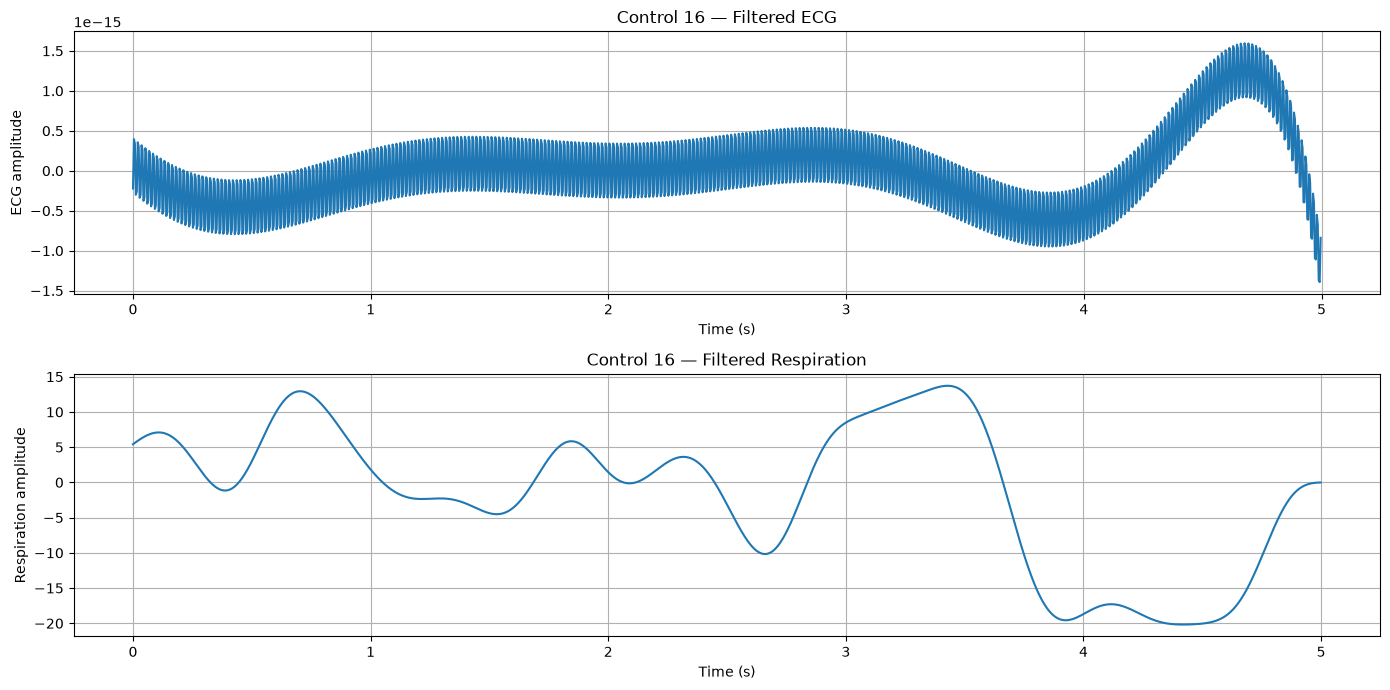

ECG standard deviation: 5.196182432452679e-16
ECG RMS: 5.196214852889323e-16
Respiration standard deviation: 9.997749532522377
Respiration RMS: 10.111925027380604


In [19]:
# Cell 17 — Visual quality check of Control 16

control_id = 16
data = control_windows[control_id]

ecg_time = np.arange(len(data["ecg_filtered"])) / ECG_FS
resp_time = np.arange(len(data["respiration_filtered"])) / RESP_FS

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ECG
axes[0].plot(ecg_time, data["ecg_filtered"])
axes[0].set_title(
    f"Control {control_id} — Filtered ECG"
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("ECG amplitude")
axes[0].grid(True)

# Respiration
axes[1].plot(resp_time, data["respiration_filtered"])
axes[1].set_title(
    f"Control {control_id} — Filtered Respiration"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Respiration amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("ECG standard deviation:",
      np.std(data["ecg_filtered"]))

print("ECG RMS:",
      np.sqrt(np.mean(data["ecg_filtered"] ** 2)))

print("Respiration standard deviation:",
      np.std(data["respiration_filtered"]))

print("Respiration RMS:",
      np.sqrt(np.mean(data["respiration_filtered"] ** 2)))

In [20]:
# Cell 18 — Find safe replacement candidates for invalid Control 16

INVALID_CONTROL = 16

invalid_start = distributed_control_windows_df.loc[
    INVALID_CONTROL - 1, "window_start"
]

selected_starts = set(
    distributed_control_windows_df["window_start"].round(6)
)

replacement_candidates = []

for start_time in safe_candidates:

    start_rounded = round(start_time, 6)

    # Skip already-selected controls
    if start_rounded in selected_starts:
        continue

    # Prefer candidates close to the invalid control
    distance = abs(start_time - invalid_start)

    replacement_candidates.append(
        (distance, start_time)
    )


replacement_candidates.sort()

print("=" * 70)
print("REPLACEMENT CONTROL CANDIDATES")
print("=" * 70)

print(f"Invalid Control 16 start: {invalid_start:.3f} s")
print("\nNearest unused safe candidates:")

for i, (distance, start_time) in enumerate(
    replacement_candidates[:10],
    start=1
):
    print(
        f"{i:2d}. "
        f"{start_time:.3f} → "
        f"{start_time + CONTROL_WINDOW:.3f} s "
        f"(distance: {distance:.3f} s)"
    )

REPLACEMENT CONTROL CANDIDATES
Invalid Control 16 start: 117206.420 s

Nearest unused safe candidates:
 1. 117173.597 → 117178.597 s (distance: 32.823 s)
 2. 117239.243 → 117244.243 s (distance: 32.823 s)
 3. 117140.773 → 117145.773 s (distance: 65.647 s)
 4. 117272.067 → 117277.067 s (distance: 65.647 s)
 5. 117107.950 → 117112.950 s (distance: 98.470 s)
 6. 117304.890 → 117309.890 s (distance: 98.470 s)
 7. 117075.127 → 117080.127 s (distance: 131.293 s)
 8. 117337.713 → 117342.713 s (distance: 131.293 s)
 9. 117042.303 → 117047.303 s (distance: 164.117 s)
10. 117370.537 → 117375.537 s (distance: 164.117 s)


REPLACEMENT CONTROL QUALITY CHECK
Window: 117173.597 → 117178.597 s
ECG samples: 1250 (expected 1250)
Respiration samples: 2500 (expected 2500)

ECG standard deviation: 0.000000
ECG RMS: 0.000000
Respiration standard deviation: 4.537893
Respiration RMS: 4.551228


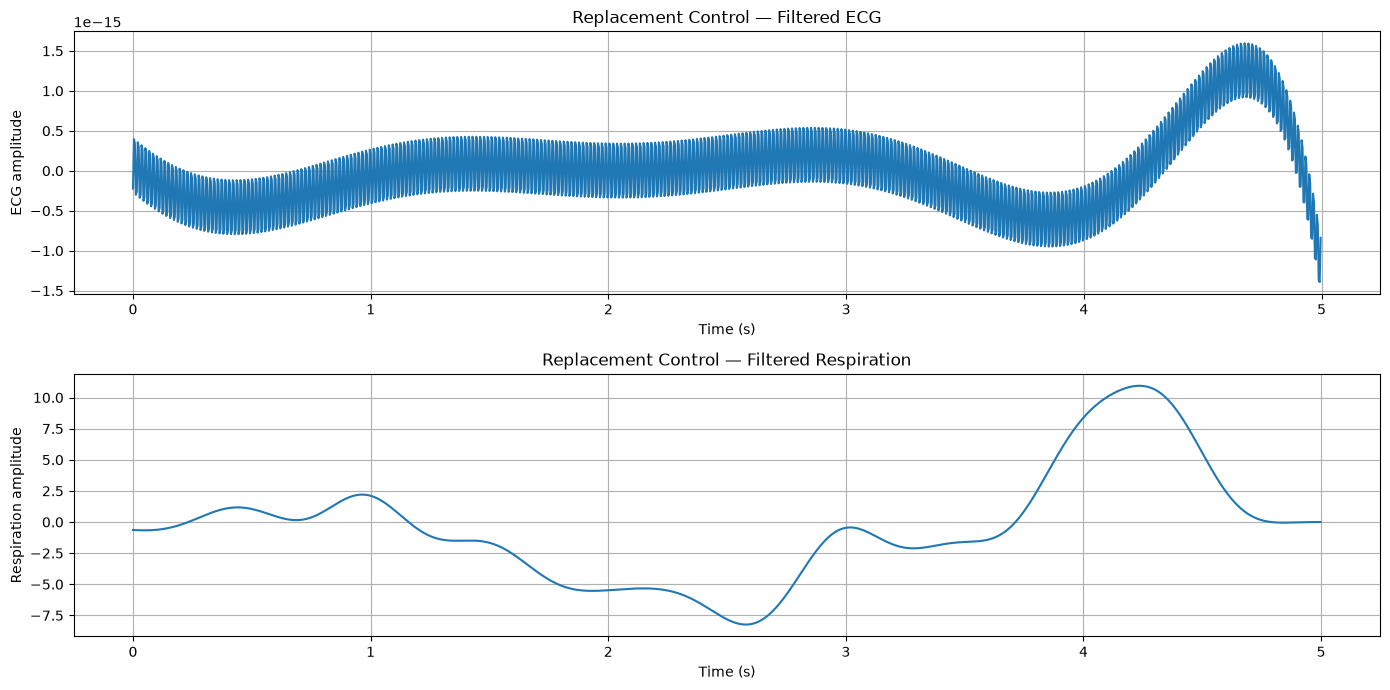

In [21]:
# Cell 19 — Load and inspect replacement control candidate

REPLACEMENT_START = 117173.597
REPLACEMENT_END = REPLACEMENT_START + CONTROL_WINDOW

# Load ECG
replacement_ecg_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir=PICS_PATH,
    sampfrom=int(REPLACEMENT_START * ECG_FS),
    sampto=int(REPLACEMENT_END * ECG_FS)
)

# Load respiration
replacement_resp_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir=PICS_PATH,
    sampfrom=int(REPLACEMENT_START * RESP_FS),
    sampto=int(REPLACEMENT_END * RESP_FS)
)

replacement_ecg_raw = replacement_ecg_record.p_signal[:, 0]
replacement_resp_raw = replacement_resp_record.p_signal[:, 0]

# Apply the same preprocessing
replacement_ecg_filtered = sosfiltfilt(
    sos_ecg_precursor,
    replacement_ecg_raw
)

replacement_resp_filtered = sosfiltfilt(
    sos_resp_precursor,
    replacement_resp_raw
)

print("=" * 70)
print("REPLACEMENT CONTROL QUALITY CHECK")
print("=" * 70)

print(
    f"Window: {REPLACEMENT_START:.3f} → "
    f"{REPLACEMENT_END:.3f} s"
)

print(
    f"ECG samples: {len(replacement_ecg_filtered)} "
    f"(expected {int(CONTROL_WINDOW * ECG_FS)})"
)

print(
    f"Respiration samples: {len(replacement_resp_filtered)} "
    f"(expected {int(CONTROL_WINDOW * RESP_FS)})"
)

print(
    f"\nECG standard deviation: "
    f"{np.std(replacement_ecg_filtered):.6f}"
)

print(
    f"ECG RMS: "
    f"{np.sqrt(np.mean(replacement_ecg_filtered ** 2)):.6f}"
)

print(
    f"Respiration standard deviation: "
    f"{np.std(replacement_resp_filtered):.6f}"
)

print(
    f"Respiration RMS: "
    f"{np.sqrt(np.mean(replacement_resp_filtered ** 2)):.6f}"
)

# Visual inspection
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ecg_time = np.arange(
    len(replacement_ecg_filtered)
) / ECG_FS

resp_time = np.arange(
    len(replacement_resp_filtered)
) / RESP_FS

axes[0].plot(
    ecg_time,
    replacement_ecg_filtered
)
axes[0].set_title(
    "Replacement Control — Filtered ECG"
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("ECG amplitude")
axes[0].grid(True)

axes[1].plot(
    resp_time,
    replacement_resp_filtered
)
axes[1].set_title(
    "Replacement Control — Filtered Respiration"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Respiration amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [22]:
# Cell 20 — Screen nearby safe candidates for usable ECG

SCREEN_COUNT = 20

screen_results = []

for distance, start_time in replacement_candidates[:SCREEN_COUNT]:

    end_time = start_time + CONTROL_WINDOW

    ecg_record = wfdb.rdrecord(
        "infant1_ecg",
        pn_dir=PICS_PATH,
        sampfrom=int(start_time * ECG_FS),
        sampto=int(end_time * ECG_FS)
    )

    ecg_raw = ecg_record.p_signal[:, 0]

    ecg_filtered = sosfiltfilt(
        sos_ecg_precursor,
        ecg_raw
    )

    ecg_std = np.std(ecg_filtered)
    ecg_rms = np.sqrt(np.mean(ecg_filtered ** 2))

    screen_results.append({
        "start": start_time,
        "end": end_time,
        "distance_from_invalid": distance,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms
    })


replacement_screen_df = pd.DataFrame(screen_results)

print("=" * 70)
print("REPLACEMENT ECG QUALITY SCREEN")
print("=" * 70)

display(replacement_screen_df.round(6))

print("\nBest candidates by ECG standard deviation:")

display(
    replacement_screen_df
    .sort_values("ecg_std", ascending=False)
    .head(10)
    .round(6)
)

REPLACEMENT ECG QUALITY SCREEN


,start,end,distance_from_invalid,ecg_std,ecg_rms
0,117173.596710,117178.596710,32.823317,0.000000,0.000000
1,117239.243345,117244.243345,32.823317,0.000000,0.000000
2,117140.773392,117145.773392,65.646635,8.490006,8.495676
3,117272.066662,117277.066662,65.646635,0.000000,0.000000
4,117107.950075,117112.950075,98.469952,0.350588,0.350668
5,117304.889980,117309.889980,98.469952,0.000000,0.000000
6,117075.126757,117080.126757,131.293270,0.188154,0.188216
7,117337.713297,117342.713297,131.293270,0.000000,0.000000
8,117042.303440,117047.303440,164.116587,0.232162,0.232499
9,117370.536615,117375.536615,164.116587,0.000000,0.000000



Best candidates by ECG standard deviation:


,start,end,distance_from_invalid,ecg_std,ecg_rms
2,117140.773392,117145.773392,65.646635,8.490006,8.495676
18,116878.186853,116883.186853,328.233175,0.401903,0.402453
4,117107.950075,117112.950075,98.469952,0.350588,0.350668
16,116911.010170,116916.010170,295.409857,0.281998,0.282378
14,116943.833487,116948.833487,262.586540,0.252888,0.252893
12,116976.656805,116981.656805,229.763222,0.249815,0.249823
10,117009.480122,117014.480122,196.939905,0.244973,0.244999
8,117042.303440,117047.303440,164.116587,0.232162,0.232499
6,117075.126757,117080.126757,131.293270,0.188154,0.188216
3,117272.066662,117277.066662,65.646635,0.000000,0.000000


SECOND REPLACEMENT CONTROL QUALITY CHECK
Window: 116878.187 → 116883.187 s
ECG samples: 1250
Respiration samples: 2500
ECG standard deviation: 0.401903
ECG RMS: 0.402453
Detected R-peaks: 15
Respiration standard deviation: 1.493901
Respiration RMS: 1.549158


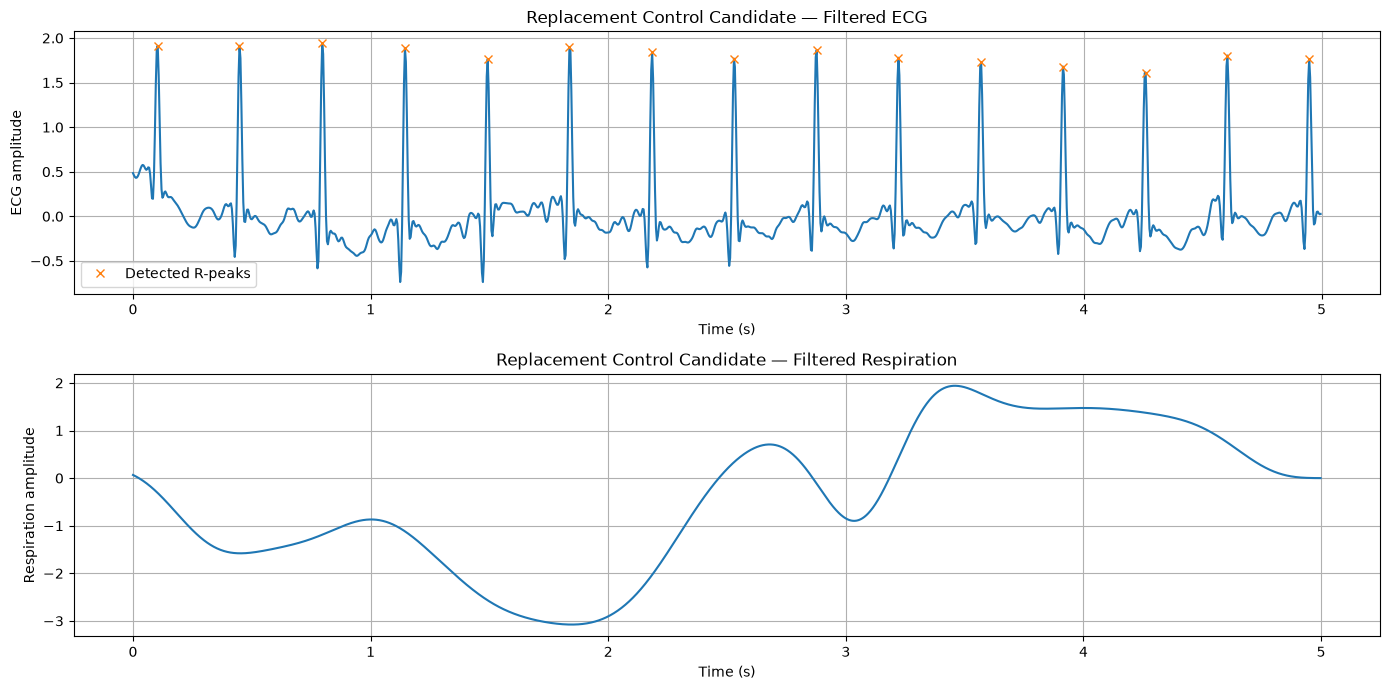

In [23]:
# Cell 21 — Visual QC of second replacement candidate

REPLACEMENT_START = 116878.186853
REPLACEMENT_END = REPLACEMENT_START + CONTROL_WINDOW

# Load ECG
replacement2_ecg_record = wfdb.rdrecord(
    "infant1_ecg",
    pn_dir=PICS_PATH,
    sampfrom=int(REPLACEMENT_START * ECG_FS),
    sampto=int(REPLACEMENT_END * ECG_FS)
)

# Load respiration
replacement2_resp_record = wfdb.rdrecord(
    "infant1_resp",
    pn_dir=PICS_PATH,
    sampfrom=int(REPLACEMENT_START * RESP_FS),
    sampto=int(REPLACEMENT_END * RESP_FS)
)

replacement2_ecg_raw = replacement2_ecg_record.p_signal[:, 0]
replacement2_resp_raw = replacement2_resp_record.p_signal[:, 0]

# Apply the same preprocessing
replacement2_ecg_filtered = sosfiltfilt(
    sos_ecg_precursor,
    replacement2_ecg_raw
)

replacement2_resp_filtered = sosfiltfilt(
    sos_resp_precursor,
    replacement2_resp_raw
)

# Detect R-peaks
replacement2_r_peaks, _ = find_peaks(
    replacement2_ecg_filtered,
    distance=int(0.25 * ECG_FS),
    prominence=0.3 * np.std(replacement2_ecg_filtered)
)

print("=" * 70)
print("SECOND REPLACEMENT CONTROL QUALITY CHECK")
print("=" * 70)

print(
    f"Window: {REPLACEMENT_START:.3f} → "
    f"{REPLACEMENT_END:.3f} s"
)

print(
    f"ECG samples: {len(replacement2_ecg_filtered)}"
)

print(
    f"Respiration samples: {len(replacement2_resp_filtered)}"
)

print(
    f"ECG standard deviation: "
    f"{np.std(replacement2_ecg_filtered):.6f}"
)

print(
    f"ECG RMS: "
    f"{np.sqrt(np.mean(replacement2_ecg_filtered ** 2)):.6f}"
)

print(
    f"Detected R-peaks: "
    f"{len(replacement2_r_peaks)}"
)

print(
    f"Respiration standard deviation: "
    f"{np.std(replacement2_resp_filtered):.6f}"
)

print(
    f"Respiration RMS: "
    f"{np.sqrt(np.mean(replacement2_resp_filtered ** 2)):.6f}"
)

# Visual inspection
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

ecg_time = np.arange(
    len(replacement2_ecg_filtered)
) / ECG_FS

resp_time = np.arange(
    len(replacement2_resp_filtered)
) / RESP_FS

axes[0].plot(
    ecg_time,
    replacement2_ecg_filtered
)

axes[0].plot(
    replacement2_r_peaks / ECG_FS,
    replacement2_ecg_filtered[replacement2_r_peaks],
    "x",
    label="Detected R-peaks"
)

axes[0].set_title(
    "Replacement Control Candidate — Filtered ECG"
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("ECG amplitude")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    resp_time,
    replacement2_resp_filtered
)

axes[1].set_title(
    "Replacement Control Candidate — Filtered Respiration"
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Respiration amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [24]:
# Cell 22 — Replace invalid Control 16 with validated candidate

# Remove the invalid Control 16
distributed_control_windows_df = (
    distributed_control_windows_df
    .drop(index=INVALID_CONTROL - 1)
    .reset_index(drop=True)
)

# Insert the validated replacement at Control 16 position
replacement_row = pd.DataFrame([{
    "window_start": REPLACEMENT_START,
    "window_end": REPLACEMENT_END,
    "risk_label": RISK_NORMAL
}])

distributed_control_windows_df = pd.concat(
    [
        distributed_control_windows_df.iloc[:INVALID_CONTROL - 1],
        replacement_row,
        distributed_control_windows_df.iloc[INVALID_CONTROL - 1:]
    ],
    ignore_index=True
)

print("=" * 70)
print("CONTROL 16 REPLACEMENT")
print("=" * 70)

print(
    f"Control 16 replaced with: "
    f"{REPLACEMENT_START:.6f} → {REPLACEMENT_END:.6f} s"
)

print(
    f"Total control windows: "
    f"{len(distributed_control_windows_df)}"
)

print(
    f"Risk labels:\n"
    f"{distributed_control_windows_df['risk_label'].value_counts().sort_index()}"
)

print("\nUpdated Control 16:")
display(
    distributed_control_windows_df.iloc[
        INVALID_CONTROL - 1:INVALID_CONTROL
    ].round(6)
)

CONTROL 16 REPLACEMENT
Control 16 replaced with: 116878.186853 → 116883.186853 s
Total control windows: 22
Risk labels:
risk_label
0    22
Name: count, dtype: int64

Updated Control 16:


,window_start,window_end,risk_label
15,116878.186853,116883.186853,0


In [25]:
# Cell 23 — Update control signal dictionary with validated Control 16

control_windows[INVALID_CONTROL] = {
    "control_number": INVALID_CONTROL,
    "window_start": REPLACEMENT_START,
    "window_end": REPLACEMENT_END,
    "ecg": replacement2_ecg_raw,
    "respiration": replacement2_resp_raw,
    "ecg_filtered": replacement2_ecg_filtered,
    "respiration_filtered": replacement2_resp_filtered,
    "risk_label": RISK_NORMAL
}

print("=" * 70)
print("CONTROL SIGNAL DICTIONARY UPDATED")
print("=" * 70)

print(f"Total control windows: {len(control_windows)}")

data = control_windows[INVALID_CONTROL]

print(
    f"Control {INVALID_CONTROL}: "
    f"{data['window_start']:.6f} → "
    f"{data['window_end']:.6f} s"
)

print(
    f"ECG samples: {len(data['ecg_filtered'])}"
)

print(
    f"Respiration samples: {len(data['respiration_filtered'])}"
)

print(
    f"ECG standard deviation: "
    f"{np.std(data['ecg_filtered']):.6f}"
)

print(
    f"Detected usable ECG signal: "
    f"{np.std(data['ecg_filtered']) > 0.01}"
)

CONTROL SIGNAL DICTIONARY UPDATED
Total control windows: 22
Control 16: 116878.186853 → 116883.186853 s
ECG samples: 1250
Respiration samples: 2500
ECG standard deviation: 0.401903
Detected usable ECG signal: True


In [26]:
# Cell 24 — Rebuild control feature dataset after QC replacement

control_feature_rows = []

for control_id, data in control_windows.items():

    features = calculate_precursor_features(
        data["ecg_filtered"],
        data["respiration_filtered"],
        ECG_FS,
        RESP_FS
    )

    features["control_number"] = control_id
    features["window_start"] = data["window_start"]
    features["window_end"] = data["window_end"]
    features["risk_label"] = RISK_NORMAL

    control_feature_rows.append(features)


control_feature_dataset = pd.DataFrame(
    control_feature_rows
)

# Put identification columns first
control_metadata_columns = [
    "control_number",
    "window_start",
    "window_end",
    "risk_label"
]

control_feature_columns = [
    col for col in control_feature_dataset.columns
    if col not in control_metadata_columns
]

control_feature_dataset = control_feature_dataset[
    control_metadata_columns + control_feature_columns
]

print("=" * 70)
print("REBUILT CONTROL FEATURE DATASET")
print("=" * 70)

print(f"Total rows: {len(control_feature_dataset)}")
print(f"Total columns: {len(control_feature_dataset.columns)}")

print("\nControl labels:")
print(
    control_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print("\nControl 16 feature check:")

display(
    control_feature_dataset[
        control_feature_dataset["control_number"] == INVALID_CONTROL
    ].round(4)
)

REBUILT CONTROL FEATURE DATASET
Total rows: 22
Total columns: 24

Control labels:
risk_label
0    22
Name: count, dtype: int64

Control 16 feature check:


,control_number,window_start,window_end,risk_label,ecg_mean,ecg_std,ecg_rms,r_peak_count,mean_rr,std_rr,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
15,16,116878.1869,116883.1869,0,0.021,0.4019,0.4025,15,0.346,0.002,...,0.0021,0.0035,-0.4101,1.4939,1.5492,2,2.456,0.0,24.43,0.0


In [27]:
# Cell 25 — Combine positive and control feature datasets

# Add a common identifier for the two classes
positive_dataset = precursor_feature_dataset.copy()
positive_dataset["sample_type"] = "precursor"

control_dataset = control_feature_dataset.copy()
control_dataset["sample_type"] = "control"

# Add missing columns so both datasets have the same structure
positive_dataset["control_number"] = np.nan
control_dataset["event_number"] = np.nan
control_dataset["event_time"] = np.nan

# Reorder columns consistently
combined_feature_dataset = pd.concat(
    [
        positive_dataset,
        control_dataset
    ],
    ignore_index=True
)

# Put metadata columns first
combined_metadata_columns = [
    "sample_type",
    "event_number",
    "control_number",
    "event_time",
    "window_start",
    "window_end",
    "time_to_event",
    "risk_label"
]

combined_feature_columns = [
    col for col in combined_feature_dataset.columns
    if col not in combined_metadata_columns
]

combined_feature_dataset = combined_feature_dataset[
    combined_metadata_columns + combined_feature_columns
]

print("=" * 70)
print("COMBINED DEVELOPMENT FEATURE DATASET")
print("=" * 70)

print(f"Total samples: {len(combined_feature_dataset)}")
print(f"Total columns: {len(combined_feature_dataset.columns)}")

print("\nClass distribution:")
print(
    combined_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print("\nSample type distribution:")
print(
    combined_feature_dataset["sample_type"]
    .value_counts()
)

print("\nDataset preview:")
display(
    combined_feature_dataset.head(10).round(4)
)

COMBINED DEVELOPMENT FEATURE DATASET
Total samples: 44
Total columns: 28

Class distribution:
risk_label
0    22
1    22
Name: count, dtype: int64

Sample type distribution:
sample_type
precursor    22
control      22
Name: count, dtype: int64

Dataset preview:


,sample_type,event_number,control_number,event_time,window_start,window_end,time_to_event,risk_label,ecg_mean,ecg_std,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,precursor,2.0,NaN,3456.512,3441.512,3446.512,10.0,1,0.0010,0.1677,...,0.0093,0.0030,-0.4830,0.8881,1.0109,4,1.3813,0.2456,44.8372,7.9414
1,precursor,2.0,NaN,3456.512,3442.512,3447.512,9.0,1,-0.0003,0.1715,...,0.0092,0.0032,-0.4637,0.8621,0.9789,3,1.3940,0.3000,45.1319,9.7127
2,precursor,2.0,NaN,3456.512,3443.512,3448.512,8.0,1,-0.0016,0.1754,...,0.0055,0.0030,-0.3519,0.7365,0.8163,5,1.1650,0.3142,54.6811,11.8966
3,precursor,2.0,NaN,3456.512,3444.512,3449.512,7.0,1,0.0020,0.1880,...,0.0044,0.0031,-0.0932,0.8409,0.8461,4,1.4220,0.2487,43.6241,8.2209
4,precursor,2.0,NaN,3456.512,3445.512,3450.512,6.0,1,0.0006,0.1897,...,0.0170,0.0175,0.1055,0.8455,0.8521,4,1.4247,0.2452,43.4914,8.0399
5,precursor,2.0,NaN,3456.512,3446.512,3451.512,5.0,1,-0.0032,0.1990,...,0.0109,0.0077,0.0646,0.7701,0.7728,3,1.2890,0.1870,47.5484,6.8980
6,precursor,2.0,NaN,3456.512,3447.512,3452.512,4.0,1,-0.0002,0.2003,...,0.0205,0.0119,0.2052,0.6843,0.7144,3,1.5090,0.4070,42.8809,11.5656
7,precursor,2.0,NaN,3456.512,3448.512,3453.512,3.0,1,0.0051,0.2026,...,0.0276,0.0155,0.2379,0.6643,0.7056,3,1.5090,0.4070,42.8809,11.5656
8,precursor,2.0,NaN,3456.512,3449.512,3454.512,2.0,1,0.0004,0.1959,...,0.0393,0.0270,0.1069,0.4665,0.4786,3,1.6850,0.2310,36.2904,4.9751
9,precursor,2.0,NaN,3456.512,3450.512,3455.512,1.0,1,0.0026,0.1925,...,0.0406,0.0269,0.0510,0.1967,0.2032,3,1.4690,0.0150,40.8484,0.4171


In [28]:
# Cell 26 — Combined dataset quality control

print("=" * 70)
print("COMBINED DATASET QUALITY CONTROL")
print("=" * 70)

# Feature columns only
feature_columns = [
    col for col in combined_feature_dataset.columns
    if col not in combined_metadata_columns
]

feature_data = combined_feature_dataset[feature_columns]

# --------------------------------------------------
# 1. Missing values
# --------------------------------------------------
nan_counts = feature_data.isna().sum()

print("\n1. Missing values:")
print(
    f"Total NaN values: {nan_counts.sum()}"
)

if nan_counts.sum() > 0:
    print("\nColumns containing NaN:")
    print(nan_counts[nan_counts > 0])

# --------------------------------------------------
# 2. Infinite values
# --------------------------------------------------
inf_count = np.isinf(
    feature_data.select_dtypes(include=np.number)
).sum().sum()

print("\n2. Infinite values:")
print(f"Total infinite values: {inf_count}")

# --------------------------------------------------
# 3. ECG signal quality
# --------------------------------------------------
print("\n3. ECG feature quality:")

ecg_std_values = combined_feature_dataset["ecg_std"]

print(
    f"Minimum ECG std: "
    f"{ecg_std_values.min():.6f}"
)

print(
    f"Maximum ECG std: "
    f"{ecg_std_values.max():.6f}"
)

print(
    f"Near-zero ECG windows (< 0.01): "
    f"{(ecg_std_values < 0.01).sum()}"
)

# --------------------------------------------------
# 4. Class balance
# --------------------------------------------------
print("\n4. Class balance:")

print(
    combined_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

# --------------------------------------------------
# 5. Duplicate windows
# --------------------------------------------------
duplicate_columns = [
    "window_start",
    "window_end",
    "risk_label"
]

duplicate_count = combined_feature_dataset.duplicated(
    subset=duplicate_columns
).sum()

print("\n5. Duplicate windows:")
print(f"Duplicate rows: {duplicate_count}")

# --------------------------------------------------
# Final status
# --------------------------------------------------
print("\n" + "=" * 70)

if (
    nan_counts.sum() == 0
    and inf_count == 0
    and (ecg_std_values >= 0.01).all()
    and duplicate_count == 0
):
    print("DATASET QC STATUS: PASS")
else:
    print("DATASET QC STATUS: REVIEW REQUIRED")

print("=" * 70)

COMBINED DATASET QUALITY CONTROL

1. Missing values:
Total NaN values: 0

2. Infinite values:
Total infinite values: 0

3. ECG feature quality:
Minimum ECG std: 0.137481
Maximum ECG std: 0.442010
Near-zero ECG windows (< 0.01): 0

4. Class balance:
risk_label
0    22
1    22
Name: count, dtype: int64

5. Duplicate windows:
Duplicate rows: 0

DATASET QC STATUS: PASS


In [29]:
# Cell 27 — Save clean development feature dataset

development_dataset_path = (
    REPORTS_DIR / "pics_precursor_development_features.csv"
)

combined_feature_dataset.to_csv(
    development_dataset_path,
    index=False
)

print("=" * 70)
print("DEVELOPMENT DATASET SAVED")
print("=" * 70)

print(f"Path: {development_dataset_path}")
print(f"Rows: {len(combined_feature_dataset)}")
print(f"Columns: {len(combined_feature_dataset.columns)}")

print("\nClass distribution:")
print(
    combined_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print("\nFile exists:", development_dataset_path.exists())

DEVELOPMENT DATASET SAVED
Path: ..\reports\pics_precursor_development_features.csv
Rows: 44
Columns: 28

Class distribution:
risk_label
0    22
1    22
Name: count, dtype: int64

File exists: True


In [31]:
# Cell 28 — Corrected comparison of precursor vs normal features

# Physiological feature columns only
analysis_feature_columns = [
    col for col in feature_columns
    if col != "risk_label"
]

# Separate the two classes
normal_data = combined_feature_dataset[
    combined_feature_dataset["risk_label"] == RISK_NORMAL
]

precursor_data = combined_feature_dataset[
    combined_feature_dataset["risk_label"] == RISK_PRECURSOR
]

# Calculate class statistics
normal_mean = normal_data[analysis_feature_columns].mean()
normal_std = normal_data[analysis_feature_columns].std()

precursor_mean = precursor_data[analysis_feature_columns].mean()
precursor_std = precursor_data[analysis_feature_columns].std()

# Build comparison table
feature_comparison = pd.DataFrame({
    "normal_mean": normal_mean,
    "normal_std": normal_std,
    "precursor_mean": precursor_mean,
    "precursor_std": precursor_std
})

# Absolute difference between class means
feature_comparison["absolute_mean_difference"] = (
    feature_comparison["precursor_mean"]
    - feature_comparison["normal_mean"]
).abs()

# Sort by largest descriptive difference
feature_comparison = feature_comparison.sort_values(
    "absolute_mean_difference",
    ascending=False
)

print("=" * 70)
print("PRECURSOR vs NORMAL FEATURE COMPARISON")
print("=" * 70)

print(f"Normal windows: {len(normal_data)}")
print(f"Precursor windows: {len(precursor_data)}")

print("\nFeature comparison:")
display(
    feature_comparison.round(4)
)

PRECURSOR vs NORMAL FEATURE COMPARISON
Normal windows: 22
Precursor windows: 22

Feature comparison:


,normal_mean,normal_std,precursor_mean,precursor_std,absolute_mean_difference
min_hr,147.2468,15.5414,131.1082,15.6840,16.1386
mean_hr,155.8423,9.0467,141.2851,14.2698,14.5572
max_hr,163.8445,16.6367,155.5017,23.0619,8.3427
std_resp_rate,4.4546,5.5008,7.9117,3.3638,3.4571
std_hr,4.3090,5.9573,7.5551,5.5870,3.2461
mean_resp_rate,43.1712,11.9234,46.1333,5.9999,2.9621
r_peak_count,12.9091,1.0193,12.0000,1.1547,0.9091
resp_peak_count,3.1364,0.8888,3.6364,0.5811,0.5000
resp_rms,0.7405,0.7571,0.3628,0.3854,0.3777
resp_std,0.6849,0.6513,0.3346,0.3667,0.3503


In [32]:
# Cell 29 — Calculate standardized mean differences (Cohen's d)
# Descriptive only; not used as a significance test.

standardized_comparison = []

for feature in analysis_feature_columns:

    normal_values = normal_data[feature].dropna()
    precursor_values = precursor_data[feature].dropna()

    normal_mean_value = normal_values.mean()
    precursor_mean_value = precursor_values.mean()

    normal_std_value = normal_values.std(ddof=1)
    precursor_std_value = precursor_values.std(ddof=1)

    # Pooled standard deviation
    n_normal = len(normal_values)
    n_precursor = len(precursor_values)

    pooled_std = np.sqrt(
        (
            (n_normal - 1) * normal_std_value**2
            + (n_precursor - 1) * precursor_std_value**2
        )
        / (n_normal + n_precursor - 2)
    )

    if pooled_std > 0:
        cohens_d = (
            precursor_mean_value - normal_mean_value
        ) / pooled_std
    else:
        cohens_d = np.nan

    standardized_comparison.append({
        "feature": feature,
        "normal_mean": normal_mean_value,
        "precursor_mean": precursor_mean_value,
        "cohens_d": cohens_d,
        "absolute_cohens_d": abs(cohens_d)
    })


standardized_comparison_df = pd.DataFrame(
    standardized_comparison
)

standardized_comparison_df = (
    standardized_comparison_df
    .sort_values(
        "absolute_cohens_d",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("STANDARDIZED FEATURE COMPARISON")
print("=" * 70)

print(
    "Note: Cohen's d is used here only for descriptive ranking."
)
print(
    "The overlapping windows are not treated as independent "
    "statistical observations."
)

display(
    standardized_comparison_df.round(4)
)

STANDARDIZED FEATURE COMPARISON
Note: Cohen's d is used here only for descriptive ranking.
The overlapping windows are not treated as independent statistical observations.


,feature,normal_mean,precursor_mean,cohens_d,absolute_cohens_d
0,mean_rr,0.3867,0.4297,1.2435,1.2435
1,mean_hr,155.8423,141.2851,-1.2185,1.2185
2,min_hr,147.2468,131.1082,-1.0337,1.0337
3,ecg_rms,0.2375,0.1803,-0.8534,0.8534
4,ecg_std,0.2374,0.1803,-0.8530,0.8530
5,r_peak_count,12.9091,12.0000,-0.8347,0.8347
6,std_resp_rate,4.4546,7.9117,0.7582,0.7582
7,resp_peak_count,3.1364,3.6364,0.6659,0.6659
8,resp_std,0.6849,0.3346,-0.6628,0.6628
9,sdnn,0.0132,0.0243,0.6314,0.6314


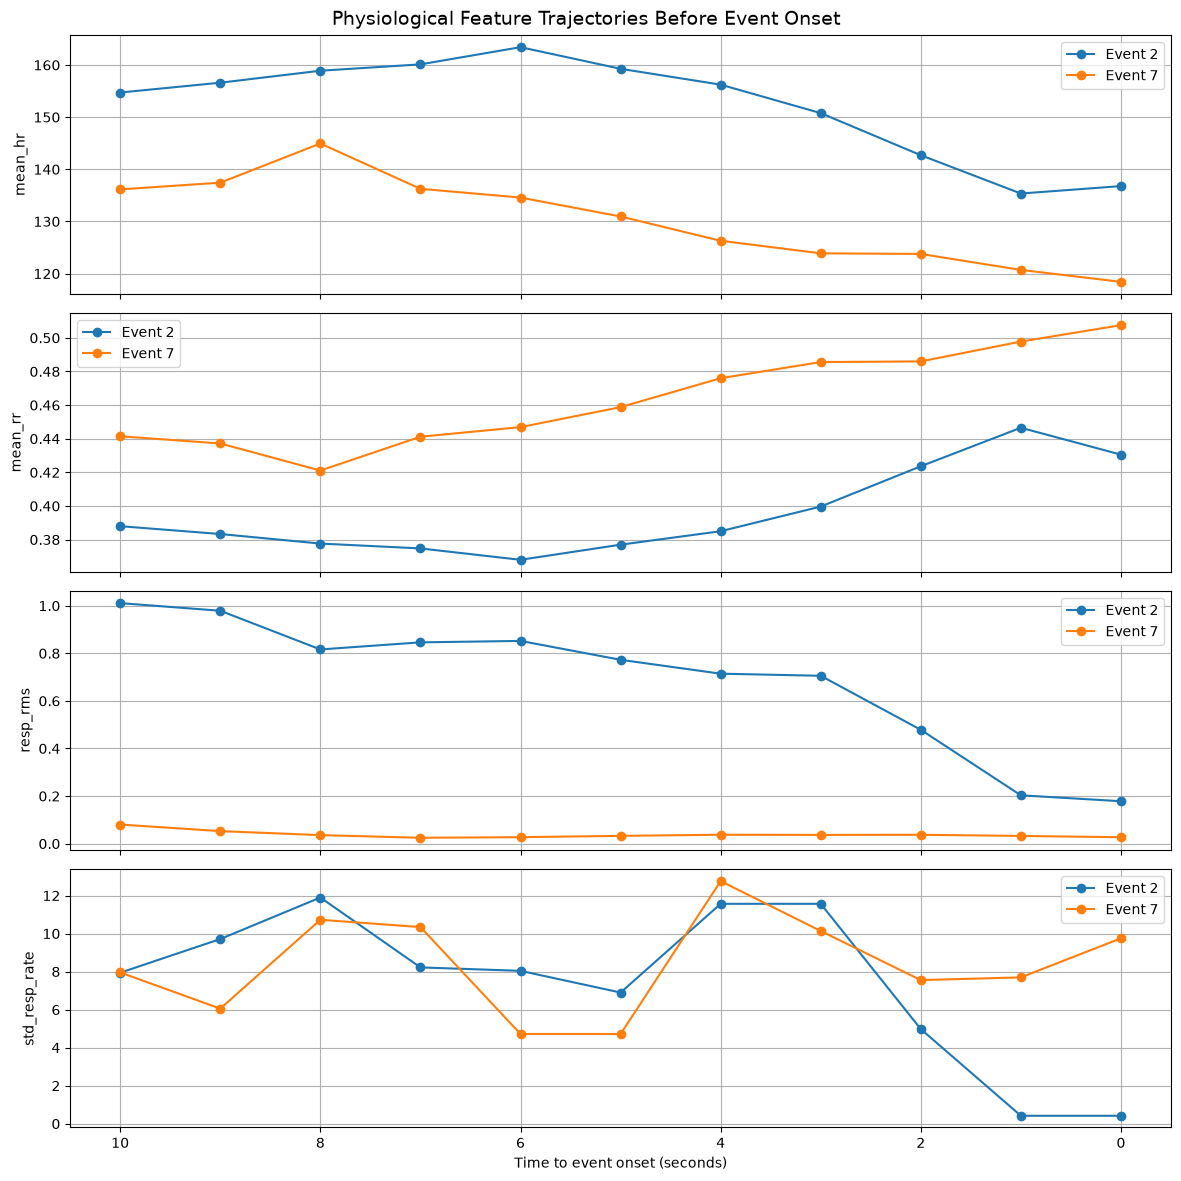

In [33]:
# Cell 30 — Visualize physiological feature trajectories toward event onset

trajectory_features = [
    "mean_hr",
    "mean_rr",
    "resp_rms",
    "std_resp_rate"
]

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True
)

for ax, feature in zip(axes, trajectory_features):

    for event_number in sorted(
        precursor_feature_dataset["event_number"].unique()
    ):

        event_data = (
            precursor_feature_dataset[
                precursor_feature_dataset["event_number"]
                == event_number
            ]
            .sort_values("time_to_event", ascending=False)
        )

        ax.plot(
            event_data["time_to_event"],
            event_data[feature],
            marker="o",
            label=f"Event {int(event_number)}"
        )

    ax.set_ylabel(feature)
    ax.grid(True)
    ax.legend()


axes[-1].set_xlabel(
    "Time to event onset (seconds)"
)

axes[-1].invert_xaxis()

fig.suptitle(
    "Physiological Feature Trajectories Before Event Onset",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [34]:
# Cell 31 — Calculate temporal trend features across the 15-second precursor

trend_features = [
    "mean_hr",
    "mean_rr",
    "resp_rms",
    "std_resp_rate"
]

trend_rows = []

for event_number in sorted(
    precursor_feature_dataset["event_number"].unique()
):

    event_data = (
        precursor_feature_dataset[
            precursor_feature_dataset["event_number"]
            == event_number
        ]
        .sort_values(
            "time_to_event",
            ascending=False
        )
    )

    # Convert to elapsed time from the beginning
    # of the precursor window.
    elapsed_time = (
        event_data["time_to_event"].max()
        - event_data["time_to_event"].to_numpy()
    )

    row = {
        "event_number": event_number
    }

    for feature in trend_features:

        values = event_data[feature].to_numpy()

        # Linear regression slope
        slope, intercept = np.polyfit(
            elapsed_time,
            values,
            1
        )

        row[f"{feature}_slope"] = slope

        # Difference between first and last windows
        row[f"{feature}_change"] = (
            values[-1] - values[0]
        )

    trend_rows.append(row)


trend_feature_dataset = pd.DataFrame(
    trend_rows
)

print("=" * 70)
print("PRECURSOR TEMPORAL TREND FEATURES")
print("=" * 70)

print(
    "Slope is measured from the beginning of the "
    "15-second precursor toward event onset."
)

display(
    trend_feature_dataset.round(4)
)

PRECURSOR TEMPORAL TREND FEATURES
Slope is measured from the beginning of the 15-second precursor toward event onset.


,event_number,mean_hr_slope,mean_hr_change,mean_rr_slope,mean_rr_change,resp_rms_slope,resp_rms_change,std_resp_rate_slope,std_resp_rate_change
0,2,-2.2653,-17.9440,0.0061,0.0425,-0.0791,-0.8325,-0.7759,-7.5243
1,7,-2.2917,-17.7242,0.0080,0.0661,-0.0028,-0.0533,0.1241,1.7940


In [35]:
# Cell 32 — Inspect current feature set

print("=" * 70)
print("CURRENT PHYSIOLOGICAL FEATURE SET")
print("=" * 70)

print(f"Total dataset columns: {len(combined_feature_dataset.columns)}")

print("\nMetadata columns:")
for col in combined_metadata_columns:
    print(f"  - {col}")

print("\nPhysiological feature columns:")
for i, col in enumerate(feature_columns, start=1):
    print(f"  {i:2d}. {col}")

print(
    f"\nTotal physiological features: "
    f"{len(feature_columns)}"
)

CURRENT PHYSIOLOGICAL FEATURE SET
Total dataset columns: 28

Metadata columns:
  - sample_type
  - event_number
  - control_number
  - event_time
  - window_start
  - window_end
  - time_to_event
  - risk_label

Physiological feature columns:
   1. ecg_mean
   2. ecg_std
   3. ecg_rms
   4. r_peak_count
   5. mean_rr
   6. std_rr
   7. mean_hr
   8. min_hr
   9. max_hr
  10. std_hr
  11. sdnn
  12. rmssd
  13. resp_mean
  14. resp_std
  15. resp_rms
  16. resp_peak_count
  17. mean_resp_interval
  18. std_resp_interval
  19. mean_resp_rate
  20. std_resp_rate

Total physiological features: 20


In [36]:
# Cell 33 — Calculate causal 5-second trend features

CAUSAL_TREND_FEATURES = [
    "mean_hr",
    "mean_rr",
    "resp_rms",
    "std_resp_rate"
]

causal_trend_rows = []

# Only positive precursor windows are currently available
# for trajectory-based trend calculation.
for event_number in sorted(
    precursor_feature_dataset["event_number"].unique()
):

    event_data = (
        precursor_feature_dataset[
            precursor_feature_dataset["event_number"]
            == event_number
        ]
        .sort_values(
            "time_to_event",
            ascending=False
        )
        .reset_index(drop=True)
    )

    for _, row in event_data.iterrows():

        trend_row = {
            "event_number": event_number,
            "window_start": row["window_start"],
            "window_end": row["window_end"],
            "time_to_event": row["time_to_event"]
        }

        # Each feature is measured within this 5-second window.
        # The current feature table represents one feature vector
        # for each 5-second window.
        #
        # With only one value per feature/window, a within-window
        # slope cannot be calculated from the feature table itself.
        # Therefore we record the structure here and leave the
        # actual signal-level slope calculation for the next step.

        for feature in CAUSAL_TREND_FEATURES:
            trend_row[f"{feature}_slope"] = np.nan

        causal_trend_rows.append(trend_row)


causal_trend_dataset = pd.DataFrame(
    causal_trend_rows
)

print("=" * 70)
print("CAUSAL TREND FEATURE STRUCTURE")
print("=" * 70)

print(
    f"Windows: {len(causal_trend_dataset)}"
)

print(
    f"Trend features planned: "
    f"{len(CAUSAL_TREND_FEATURES)}"
)

display(
    causal_trend_dataset.head(10)
)

CAUSAL TREND FEATURE STRUCTURE
Windows: 22
Trend features planned: 4


,event_number,window_start,window_end,time_to_event,mean_hr_slope,mean_rr_slope,resp_rms_slope,std_resp_rate_slope
0,2,3441.512,3446.512,10.0,NaN,NaN,NaN,NaN
1,2,3442.512,3447.512,9.0,NaN,NaN,NaN,NaN
2,2,3443.512,3448.512,8.0,NaN,NaN,NaN,NaN
3,2,3444.512,3449.512,7.0,NaN,NaN,NaN,NaN
4,2,3445.512,3450.512,6.0,NaN,NaN,NaN,NaN
5,2,3446.512,3451.512,5.0,NaN,NaN,NaN,NaN
6,2,3447.512,3452.512,4.0,NaN,NaN,NaN,NaN
7,2,3448.512,3453.512,3.0,NaN,NaN,NaN,NaN
8,2,3449.512,3454.512,2.0,NaN,NaN,NaN,NaN
9,2,3450.512,3455.512,1.0,NaN,NaN,NaN,NaN


In [37]:
# Cell 34 — Calculate causal trends using only current and past windows

CAUSAL_TREND_FEATURES = [
    "mean_hr",
    "mean_rr",
    "resp_rms",
    "std_resp_rate"
]

causal_trend_rows = []

for event_number in sorted(
    precursor_feature_dataset["event_number"].unique()
):

    event_data = (
        precursor_feature_dataset[
            precursor_feature_dataset["event_number"]
            == event_number
        ]
        .sort_values(
            "time_to_event",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # elapsed time from the beginning of the precursor
    elapsed_time = (
        event_data["window_start"]
        - event_data["window_start"].iloc[0]
    ).to_numpy()

    for i in range(len(event_data)):

        row = event_data.iloc[i]

        trend_row = {
            "event_number": event_number,
            "window_start": row["window_start"],
            "window_end": row["window_end"],
            "time_to_event": row["time_to_event"]
        }

        # Use ONLY windows 0 ... i.
        # No future windows are allowed.
        history_time = elapsed_time[:i + 1]

        for feature in CAUSAL_TREND_FEATURES:

            history_values = (
                event_data[feature]
                .iloc[:i + 1]
                .to_numpy()
            )

            # Need at least two observations for a slope
            if len(history_values) >= 2:
                slope, _ = np.polyfit(
                    history_time,
                    history_values,
                    1
                )
            else:
                slope = np.nan

            trend_row[f"{feature}_causal_slope"] = slope

        causal_trend_rows.append(trend_row)


causal_trend_dataset = pd.DataFrame(
    causal_trend_rows
)

print("=" * 70)
print("CAUSAL TEMPORAL TREND FEATURES")
print("=" * 70)

print(
    "Each slope uses only the current window and "
    "earlier windows."
)

print(
    f"\nTotal windows: {len(causal_trend_dataset)}"
)

print(
    f"Total causal trend features: "
    f"{len(CAUSAL_TREND_FEATURES)}"
)

print("\nCausal trend table:")

display(
    causal_trend_dataset.round(4)
)

CAUSAL TEMPORAL TREND FEATURES
Each slope uses only the current window and earlier windows.

Total windows: 22
Total causal trend features: 4

Causal trend table:


,event_number,window_start,window_end,time_to_event,mean_hr_causal_slope,mean_rr_causal_slope,resp_rms_causal_slope,std_resp_rate_causal_slope
0,2,3441.512,3446.512,10.0,NaN,NaN,NaN,NaN
1,2,3442.512,3447.512,9.0,1.8817,-0.0047,-0.0320,1.7714
2,2,3443.512,3448.512,8.0,2.0900,-0.0052,-0.0973,1.9776
3,2,3444.512,3449.512,7.0,1.8492,-0.0045,-0.0657,0.3023
4,2,3445.512,3450.512,6.0,2.0904,-0.0049,-0.0451,-0.1295
5,2,3446.512,3451.512,5.0,1.2684,-0.0030,-0.0440,-0.3974
6,2,3447.512,3452.512,4.0,0.5135,-0.0011,-0.0452,0.0495
7,2,3448.512,3453.512,3.0,-0.2987,0.0010,-0.0427,0.2316
8,2,3449.512,3454.512,2.0,-1.1959,0.0035,-0.0538,-0.1382
9,2,3450.512,3455.512,1.0,-1.9882,0.0058,-0.0715,-0.5675


In [38]:
# Cell 35 — Signal-level trends within each 5-second window

def calculate_signal_trends(signal_data, fs):
    """
    Calculate a linear amplitude trend within one window.
    Uses only samples contained inside the current window.
    """

    if len(signal_data) < 2:
        return np.nan

    time_axis = np.arange(len(signal_data)) / fs

    slope, _ = np.polyfit(
        time_axis,
        signal_data,
        1
    )

    return slope


signal_trend_rows = []

# --------------------------------------------------
# Positive precursor windows
# --------------------------------------------------
for window in sliding_windows:

    signal_trend_rows.append({
        "sample_type": "precursor",
        "event_number": window["event_number"],
        "control_number": np.nan,
        "window_start": window["window_start"],
        "window_end": window["window_end"],
        "time_to_event": window["time_to_event"],
        "ecg_amplitude_slope": calculate_signal_trends(
            window["ecg"],
            ECG_FS
        ),
        "resp_amplitude_slope": calculate_signal_trends(
            window["respiration"],
            RESP_FS
        ),
        "risk_label": RISK_PRECURSOR
    })


# --------------------------------------------------
# Control windows
# --------------------------------------------------
for control_id, data in control_windows.items():

    signal_trend_rows.append({
        "sample_type": "control",
        "event_number": np.nan,
        "control_number": control_id,
        "window_start": data["window_start"],
        "window_end": data["window_end"],
        "time_to_event": np.nan,
        "ecg_amplitude_slope": calculate_signal_trends(
            data["ecg_filtered"],
            ECG_FS
        ),
        "resp_amplitude_slope": calculate_signal_trends(
            data["respiration_filtered"],
            RESP_FS
        ),
        "risk_label": RISK_NORMAL
    })


signal_trend_dataset = pd.DataFrame(
    signal_trend_rows
)

print("=" * 70)
print("SIGNAL-LEVEL TREND FEATURES")
print("=" * 70)

print(
    f"Total windows: {len(signal_trend_dataset)}"
)

print("\nClass distribution:")
print(
    signal_trend_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print("\nTrend feature summary:")
display(
    signal_trend_dataset[
        [
            "sample_type",
            "event_number",
            "control_number",
            "window_start",
            "time_to_event",
            "ecg_amplitude_slope",
            "resp_amplitude_slope",
            "risk_label"
        ]
    ].round(6)
)

SIGNAL-LEVEL TREND FEATURES
Total windows: 44

Class distribution:
risk_label
0    22
1    22
Name: count, dtype: int64

Trend feature summary:


,sample_type,event_number,control_number,window_start,time_to_event,ecg_amplitude_slope,resp_amplitude_slope,risk_label
0,precursor,2.0,NaN,3441.512000,10.0,0.002884,0.073113,1
1,precursor,2.0,NaN,3442.512000,9.0,-0.000148,0.061236,1
2,precursor,2.0,NaN,3443.512000,8.0,-0.003362,0.069242,1
3,precursor,2.0,NaN,3444.512000,7.0,0.000593,0.197901,1
4,precursor,2.0,NaN,3445.512000,6.0,-0.001666,0.186897,1
5,precursor,2.0,NaN,3446.512000,5.0,0.000204,0.120693,1
6,precursor,2.0,NaN,3447.512000,4.0,-0.000827,-0.021486,1
7,precursor,2.0,NaN,3448.512000,3.0,0.000791,-0.145129,1
8,precursor,2.0,NaN,3449.512000,2.0,0.003522,-0.051405,1
9,precursor,2.0,NaN,3450.512000,1.0,0.001889,0.051487,1
